In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the data and display the head(i.e the top records)
df = pd.read_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\spotify.csv")
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Lucky Man,Montgomery Gentry,spotify:track:4GiXBCUF7H6YfNQsnBRIzl,0.578,0.471,4,-7.270,1,0.0289,0.368000,0.00000,0.159,0.532,133.061,196707,4,30.88059,13,1
1,On The Hotline,Pretty Ricky,spotify:track:1zyqZONW985Cs4osz9wlsu,0.704,0.854,10,-5.477,0,0.1830,0.018500,0.00000,0.148,0.688,92.988,242587,4,41.51106,10,1
2,Clouds Of Dementia,Candlemass,spotify:track:6cHZf7RbxXCKwEkgAZT4mY,0.162,0.836,9,-3.009,1,0.0473,0.000111,0.00457,0.174,0.300,86.964,338893,4,65.32887,13,0
3,"Heavy Metal, Raise Hell!",Zwartketterij,spotify:track:2IjBPp2vMeX7LggzRN3iSX,0.188,0.994,4,-3.745,1,0.1660,0.000007,0.07840,0.192,0.333,148.440,255667,4,58.59528,9,0
4,I Got A Feelin',Billy Currington,spotify:track:1tF370eYXUcWwkIvaq3IGz,0.630,0.764,2,-4.353,1,0.0275,0.363000,0.00000,0.125,0.631,112.098,193760,4,22.62384,10,1


In [3]:
df.tail()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
5867,Summer Rain,Carl Thomas,spotify:track:0NBHHa8wwwmBnn3aAzX5wJ,0.667,0.6270,6,-10.488,0,0.0654,0.0972,0.000052,0.1110,0.784,186.081,232560,4,40.87045,10,1
5868,And I,Ciara,spotify:track:1Jp9n1uHB72CfK31j4mEPh,0.691,0.3890,6,-10.125,1,0.0653,0.2550,0.000000,0.0981,0.437,122.219,233840,4,81.77735,7,1
5869,"Mass in B minor BWV 232, Missa: Duetto - Chris...",Johann Sebastian Bach,spotify:track:4NIOi1ImMfdufRTsgoKjbD,0.297,0.0773,2,-23.839,1,0.0620,0.9510,0.000217,0.1210,0.401,75.916,275560,4,37.51903,11,0
5870,Loog,The Clean,spotify:track:2Qyj2nUdm8y37TCCzDasFn,0.390,0.6010,7,-8.236,0,0.0291,0.0313,0.947000,0.1190,0.439,116.122,223627,4,39.84092,11,0
5871,What The World Needs,Wynonna,spotify:track:38Q6YF0TO7E4Dq6K0zdVUk,0.539,0.7400,0,-5.566,0,0.0490,0.1940,0.000000,0.0760,0.675,170.054,217160,4,24.95471,13,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5872 entries, 0 to 5871
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track             5872 non-null   str    
 1   artist            5872 non-null   str    
 2   uri               5872 non-null   str    
 3   danceability      5872 non-null   float64
 4   energy            5872 non-null   float64
 5   key               5872 non-null   int64  
 6   loudness          5872 non-null   float64
 7   mode              5872 non-null   int64  
 8   speechiness       5872 non-null   float64
 9   acousticness      5872 non-null   float64
 10  instrumentalness  5872 non-null   float64
 11  liveness          5872 non-null   float64
 12  valence           5872 non-null   float64
 13  tempo             5872 non-null   float64
 14  duration_ms       5872 non-null   int64  
 15  time_signature    5872 non-null   int64  
 16  chorus_hit        5872 non-null   float64
 17  sectio

In [5]:
print("Missing values:\n",df.isnull().sum())
print("\nDuplicate values: ",df.duplicated().sum())

Missing values:
 track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

Duplicate values:  0


In [6]:
print("shape: ",df.shape)

shape:  (5872, 19)


In [7]:
print("Statistical summary:\n",df.describe())

Statistical summary:
        danceability       energy          key     loudness         mode  \
count   5872.000000  5872.000000  5872.000000  5872.000000  5872.000000   
mean       0.542931     0.694511     5.276396    -7.449258     0.645095   
std        0.190003     0.237792     3.564153     5.102543     0.478525   
min        0.058800     0.000348     0.000000   -47.327000     0.000000   
25%        0.416000     0.567000     2.000000    -8.315000     0.000000   
50%        0.556000     0.744000     5.000000    -6.041500     1.000000   
75%        0.681000     0.885000     8.000000    -4.562500     1.000000   
max        0.986000     0.999000    11.000000     1.137000     1.000000   

       speechiness  acousticness  instrumentalness     liveness      valence  \
count  5872.000000   5872.000000       5872.000000  5872.000000  5872.000000   
mean      0.092360      0.214374          0.150917     0.196141     0.482262   
std       0.094997      0.296511          0.301452     0.16196

In [8]:
print("Target distribution: ")
print(df['target'].value_counts())
print(f"\nHit %:{df['target'].mean()*100:.2f}%")

Target distribution: 
target
1    2936
0    2936
Name: count, dtype: int64

Hit %:50.00%


In [9]:
df_new = df.drop(columns=['uri','track','artist'])
print("After dropping columns: ",df_new)

After dropping columns:        danceability  energy  key  loudness  mode  speechiness  acousticness  \
0            0.578  0.4710    4    -7.270     1       0.0289      0.368000   
1            0.704  0.8540   10    -5.477     0       0.1830      0.018500   
2            0.162  0.8360    9    -3.009     1       0.0473      0.000111   
3            0.188  0.9940    4    -3.745     1       0.1660      0.000007   
4            0.630  0.7640    2    -4.353     1       0.0275      0.363000   
...            ...     ...  ...       ...   ...          ...           ...   
5867         0.667  0.6270    6   -10.488     0       0.0654      0.097200   
5868         0.691  0.3890    6   -10.125     1       0.0653      0.255000   
5869         0.297  0.0773    2   -23.839     1       0.0620      0.951000   
5870         0.390  0.6010    7    -8.236     0       0.0291      0.031300   
5871         0.539  0.7400    0    -5.566     0       0.0490      0.194000   

      instrumentalness  liveness  vale

In [10]:
print("Shape of the new dataframe: ",df_new.shape)

Shape of the new dataframe:  (5872, 16)


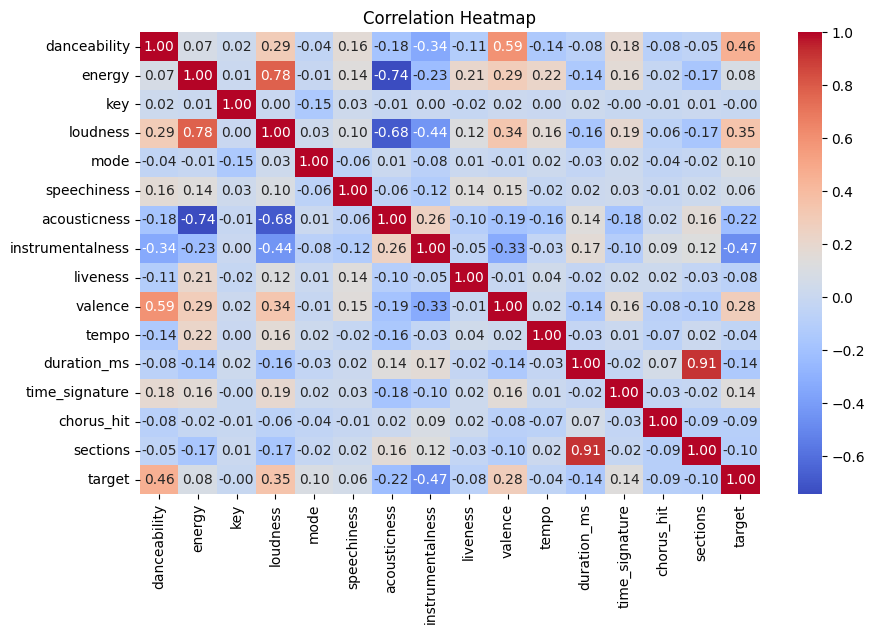

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
#Save the image for future reference
plt.savefig("correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [13]:
#save the dataset after dropping columns
df_new.to_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\df_new.csv", index=False)

In [14]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 5872 entries, 0 to 5871
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      5872 non-null   float64
 1   energy            5872 non-null   float64
 2   key               5872 non-null   int64  
 3   loudness          5872 non-null   float64
 4   mode              5872 non-null   int64  
 5   speechiness       5872 non-null   float64
 6   acousticness      5872 non-null   float64
 7   instrumentalness  5872 non-null   float64
 8   liveness          5872 non-null   float64
 9   valence           5872 non-null   float64
 10  tempo             5872 non-null   float64
 11  duration_ms       5872 non-null   int64  
 12  time_signature    5872 non-null   int64  
 13  chorus_hit        5872 non-null   float64
 14  sections          5872 non-null   int64  
 15  target            5872 non-null   int64  
dtypes: float64(10), int64(6)
memory usage: 734.1 KB


In [15]:
#Check for missing values and duplicates in the new dataframe
print("Missing values in new dataframe:\n",df_new.isnull().sum())
print("\nDuplicate values in new dataframe: ",df_new.duplicated().sum())

Missing values in new dataframe:
 danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

Duplicate values in new dataframe:  28


In [16]:
#Drop the duplicates
df_new = df_new.drop_duplicates()
print("After dropping duplicates, shape: ",df_new.shape)

After dropping duplicates, shape:  (5844, 16)


In [17]:
print("Missing values in new dataframe:\n",df_new.isnull().sum())
print("\nDuplicate values in new dataframe: ",df_new.duplicated().sum())

Missing values in new dataframe:
 danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

Duplicate values in new dataframe:  0


In [18]:
#Save the cleaned data to a new CSV file
df_new.to_csv("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\data\\df_cleaned.csv", index=False)

In [20]:
#shape of the cleaned dataframe
print("Shape of the cleaned dataframe: ",df_new.shape)

Shape of the cleaned dataframe:  (5844, 16)


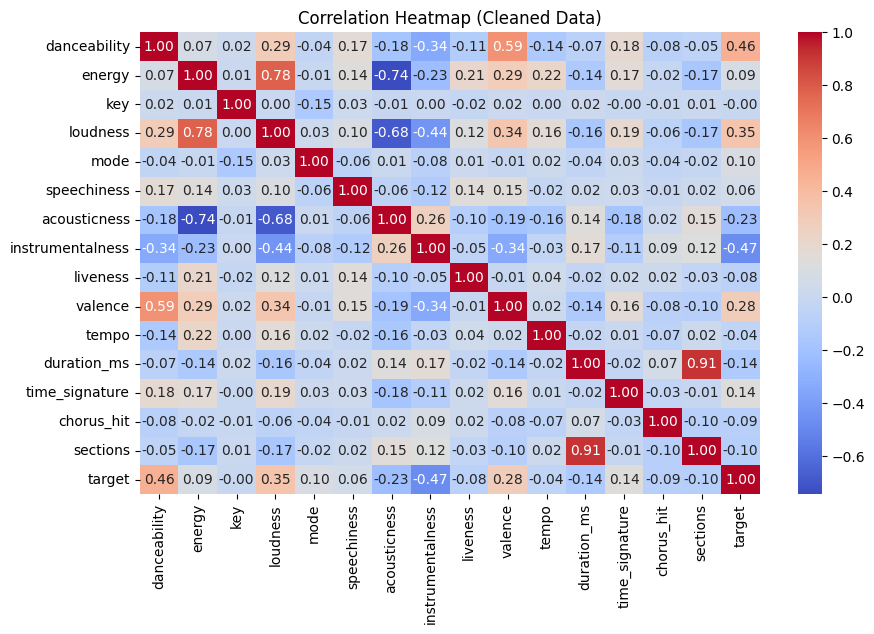

In [21]:
#heatmap of the cleaned dataframe
plt.figure(figsize=(10,6))
sns.heatmap(df_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Cleaned Data)")
plt.show()

In [22]:
#Save the heatmap in the graphs folder
plt.savefig("C:\\Users\\kotip\\Desktop\\Spotify_Hit _Prediction\\results\\graphs\\correlation_heatmap_cleaned.png")

<Figure size 640x480 with 0 Axes>